# Advanced Analytics: Prediciendo la Eliminación de Un Jugador

El objetivo de este Notebook es construir un modelo de claseificación de Machine Learning que sea capaz de predecir si un jugador de Monopoly perderá el juego basado en su estado actual. 

Este modelo usa indicadores económicos, activos, posición en el tablero, y variables de progresión del juego para estimar la probabilidad de eliminación. 

In [0]:
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

In [0]:
df = spark.table("workspace.default.monopoly_clean")

display(df.limit(5))

game_id,turn,player,player_number,position,dice_value,cash,mortgageable_amount,jail_count,exit_jail,free_visit,owned_roads,owned_stations,owned_utilities,total_properties,mortgaged_roads,mortgaged_stations,mortgaged_utilities,monopolies,houses,hotels,bank_cash,net_worth,has_lost
1000,0,player1,1,10,10,1500,0,0,false,true,0,0,0,0,0,0,0,0,0,0,5000,1500,false
1000,0,player2,2,5,5,1300,100,0,false,false,0,1,0,1,0,0,0,0,0,0,5200,1400,false
1000,1,player1,1,14,4,1340,80,0,false,false,1,0,0,1,0,0,0,0,0,0,5360,1420,false
1000,1,player2,2,11,6,1160,170,0,false,false,1,1,0,2,0,0,0,0,0,0,5500,1330,false
1000,2,player1,1,23,9,1120,190,0,false,false,2,0,0,2,0,0,0,0,0,0,5720,1310,false


In [0]:
display(
    df.groupBy("has_lost")
      .count()
      .orderBy("has_lost")
)

has_lost,count
false,3223870
true,3478


In [0]:
from pyspark.sql.functions import col

df = spark.table("workspace.default.monopoly_clean")

df = df.withColumn(
    "label",
    col("has_lost").cast("integer")
)

In [0]:
feature_cols = [
    "position",
    "dice_value",
    "cash",
    "mortgageable_amount",
    "net_worth",
    "jail_count",
    "owned_roads",
    "owned_stations",
    "owned_utilities",
    "total_properties",
    "mortgaged_roads",
    "mortgaged_stations",
    "mortgaged_utilities",
    "monopolies",
    "houses",
    "hotels",
    "bank_cash"
]

In [0]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

dataset = assembler.transform(df).select("features", "label")

In [0]:
train, test = dataset.randomSplit([0.8, 0.2], seed=42)

print("Training records:", train.count())
print("Testing records:", test.count())

Training records: 2581559
Testing records: 645789


In [0]:
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=100,
    maxDepth=8,
    seed=42
)

model = rf.fit(train)

In [0]:
predictions = model.transform(test)

display(
    predictions.select(
        "label",
        "prediction",
        "probability"
    )
)

label,prediction,probability
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9988798611193432"",""0.0011201388806568204""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9990900330498731"",""9.099669501269059E-4""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9994860991324576"",""5.13900867542434E-4""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9994904093807064"",""5.095906192936809E-4""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9995679195461739"",""4.320804538260711E-4""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9996908690933367"",""3.0913090666333167E-4""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9997328971201805"",""2.671028798194278E-4""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9995671295203181"",""4.32870479681923E-4""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9997524447118241"",""2.475552881758698E-4""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9994623990359374"",""5.376009640626076E-4""]}"


In [0]:
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

print(f"Accuracy: {accuracy:.4f}")

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label"
)

auc = auc_evaluator.evaluate(predictions)

print(f"AUC: {auc:.4f}")

Accuracy: 0.9989
AUC: 0.9807


In [0]:
display(
    predictions.groupBy("label", "prediction")
               .count()
               .orderBy("label", "prediction")
)

label,prediction,count
0,0.0,645073
1,0.0,716


In [0]:
importance = [
    (feature, float(score))
    for feature, score in zip(feature_cols, model.featureImportances)
]

importance = sorted(
    importance,
    key=lambda x: x[1],
    reverse=True
)

importance_df = spark.createDataFrame(
    importance,
    schema=["Feature", "Importance"]
)

display(importance_df)

Feature,Importance
net_worth,0.17672371796629896
position,0.13063553155355645
mortgaged_stations,0.08344002243098796
mortgageable_amount,0.08323200175445589
mortgaged_roads,0.07458745793958103
mortgaged_utilities,0.06676131997511627
cash,0.06274275222253758
houses,0.0562186974055949
bank_cash,0.0530260542014182
total_properties,0.050005412667484296


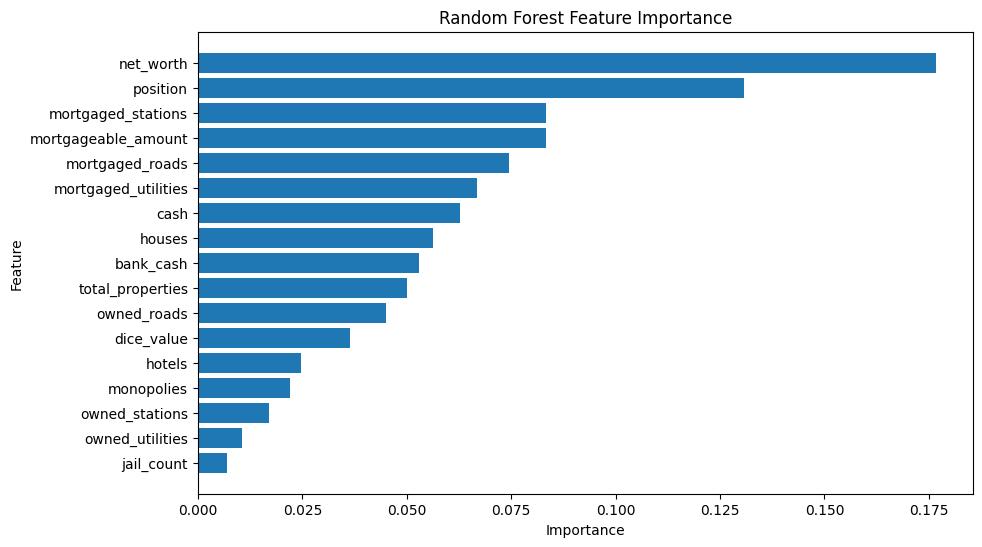

In [0]:
import matplotlib.pyplot as plt

importance_pd = importance_df.toPandas()

plt.figure(figsize=(10,6))

plt.barh(
    importance_pd["Feature"],
    importance_pd["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()